# Análise Estatíticas Descritvas por Fator

## Bibliotecas

In [1]:
import sys
from pathlib import Path
import warnings
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# 1. Configurações gerais
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 2. Ativação do autoreload via API do IPython (compatível e sem SyntaxError no VS Code)
try:
    get_ipython().run_line_magic('load_ext', 'autoreload')
    get_ipython().run_line_magic('autoreload', '2')
except NameError:
    pass

# 3. Adiciona a pasta scripts ao caminho do Python ANTES de importar os módulos locais
sys.path.append(str(Path.cwd().parent / 'scripts'))

# 4. Importação dos módulos do seu projeto
from prepara_dados_fator import prepara_dados_fator
from executa_teste_quiquadrado import executa_teste_quiquadrado
from verifica_pressupostos_anova import verifica_pressupostos_anova
from executa_anova_oneway import executa_anova_oneway
from executa_kruskal_wallis import executa_kruskal_wallis
from executa_tukey_hsd import executa_tukey_hsd
from executa_posthoc_mannwhitney import executa_posthoc_mannwhitney
from executa_posthoc_quiquadrado import executa_posthoc_quiquadrado
from plota_boxplot_fator import plota_boxplot_fator
from plota_barras_horizontais import plota_barras_horizontais
from formata_tabela import formata_tabela
from gera_agrup_poshoc import gera_agrup_poshoc



## Arquivo de dados

In [2]:
df = pd.read_parquet('../Data/Candidatos_Tratados.parquet')

## Etapas de Análise Estatística Descritiva por Fator

As seguintes etapas serão seguidas para todos os fatores analisados:

### 1. Análise Estatística Descritiva

Nesta etapa, é realizado o agrupamento da taxa de conclusão real de cada Instituto Federal (nível institucional). Os resultados são organizados em uma tabela comparando as medidas descritivas (mínimo, mediana, média simples e desvio-padrão dos IFs) com a Taxa Ponderada Global dos alunos na Rede Federal.

### 2. Teste Qui-Quadrado 

O Teste do Qui-quadrado considera que cada estudante possui o mesmo peso na análise, independentemente se unidade IF de origem ter 500 ou 50 mil alunos. O objetivo é responder se a probabilidade de conclusão ou evasão do aluno está estatisticamente associada ao fator sociodemográfico avaliado.

### 3. Gráfico de Barras Horizontais das Médias Ponderadas

Elaboração de gráfico de barras horizontais para comparação das médias de cada classe do fator, independemente da unidade do IF. Desta forma, cada barra no gráfico representa a média ponderada da taxa de conclusão por fator. Sendo assim, IFs com maior número de alunos influenciam mais no cálculo da média.

### 4. Teste de normalidade

O teste de Normalidade avalia se os pressupostos de Gauss-Markov (normalidade dos resíduos via Shapiro-Wilk e homogeneidade das variâncias via Levene) são atendidos pelo fator. 

### 5. ANOVA One-Way ou Teste de Kruskal-Wallis

Conforme os pressupostos de Gauss-Markov são ou não atendidas, opta-se por usar para a análise  o método paramétrico (Anova de Fisher) ou o não-paramétrico (Teste de Kruskal-Wallis ou ANOVA por postos). Ambos os testes avaliam se a influência do fator sobre as taxas institucionais é estatisticamente significativa. O que diferencia estes dois métodos estatísticos do Qui-Quadrado é a base de observação. Enquanto no Qui-Quadrado, a base é o estudante, na ANOVA e no Kruskal-Wallis, a base é a taxa de cada Instituto Federal, tendo cada instituição o mesmo peso independente do número de estudantes matriculados.

### 6. Teste de Comparação de Médias

A medida que os testes anteriores (Anova de Fisher ou Teste de Kruskal_Wallis) indicarem diferença estatisticamente signifcativa ($p < 0,05$), a próxima análise e o Teste de Comparação de Médias. Este teste tem a finalidade de identificar entre quais categorias do fator se as diferenças foram estatísticamene significativas. Para isso, utiliza-se o Teste de Tukey HSD, se o modelo for a ANOVA - paramétrica, ou o Teste de Mann-Whitney com correção de Bonferroni, se o modelo for o Kruskal-Wallis - não-paramétrico.

### 7. Gráfico de Barras Horizontais das Médias por IF

Elaboração de gráfico de barras horizontais para mostrar as médias de cada classe do fator, considerando como unidade de observação a média da taxa de conclusão de cada unidade de IF por fator. Neste caso, cada barra representa a média das médias da taxa de aprovação por unidade do IF. Sendo assim, a 

### 8. Gráfico de Boxplot com Strip Plot das Médias por IF

Elaboração de gráfico boxplot para visualização da dispersão das taxas das instituições, destacando as medianas, a média de cada grupo, cada IF individualizado e a linha de referência da média nacional.


    

REGIAO

Etapa 01 - Análise Estatística Descritiva Inicial

Tabela 01. Análise Estatística Descritiva
--------------------------------------------------------------------------------------------
REGIAO          N_IFS  TAXA_MEDIA_IF  DESVIO_PADRAO  MEDIANA    MIN    MAX  TAXA_MEDIA_GERAL
--------------------------------------------------------------------------------------------
Sul                 6          59.98          17.37    53.95  41.74  81.57             78.52
Sudeste             9          59.79          14.52    53.69  43.96  80.42             63.44
Norte               7          48.88           5.38    45.73  44.18  57.36             48.95
Centro-Oeste        5          47.23          14.06    45.04  35.05  69.87             41.97
Nordeste           11          42.38           7.38    42.47  30.29  56.39             43.64
--------------------------------------------------------------------------------------------

Etapa 02 - Teste Qui-Quadrado e V de Cramér (Nível Discente)


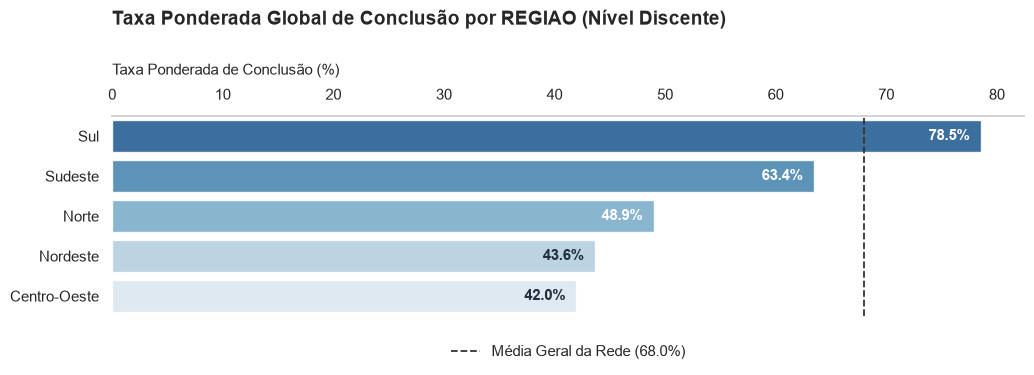


Etapa 04 - Verificação dos Pressupostos da ANOVA (Gauss-Markov)

p-valor Shapiro-Wilk (Normalidade): 6.3632e-02
p-valor Levene (Homocedasticidade): 1.1298e-01

Etapa 05 - ANOVA One-Way (Paramétrica) para REGIAO

ANOVA: F = 3.6793 | p-valor = 1.3863e-02

Etapa 06 - Teste de Comparações Múltiplas (Tukey HSD) para REGIAO

Tabela 04. Estatística Descritiva Institucional para REGIAO (Nível Instituição)
---------------------------------------------------------------------------------------------------
REGIAO          N_IFS  TAXA_MEDIA_IF  DESVIO_PADRAO  MEDIANA    MIN    MAX  TAXA_MEDIA_GERAL  GRUPO
---------------------------------------------------------------------------------------------------
Sul                 6          59.98          17.37    53.95  41.74  81.57             78.52      a
Sudeste             9          59.79          14.52    53.69  43.96  80.42             63.44      a
Norte               7          48.88           5.38    45.73  44.18  57.36             48.95     a

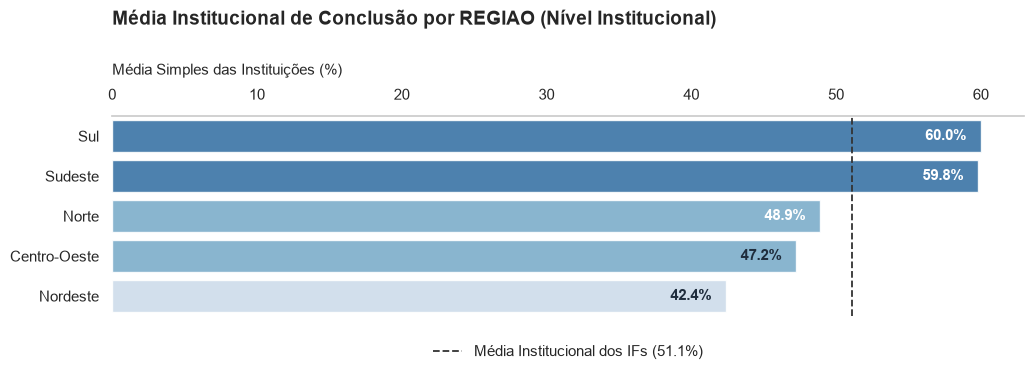


Etapa 08 - Gráfico de Boxplot com Strip Plot das Médias por IF para REGIAO



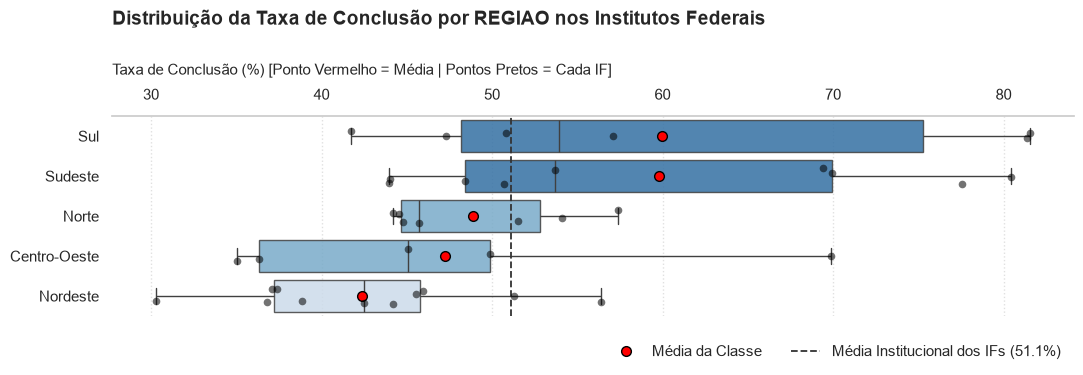

ETNIA

Etapa 01 - Análise Estatística Descritiva Inicial

Tabela 01. Análise Estatística Descritiva
-----------------------------------------------------------------------------------------
ETNIA       N_IFS  TAXA_MEDIA_IF  DESVIO_PADRAO  MEDIANA    MIN     MAX  TAXA_MEDIA_GERAL
-----------------------------------------------------------------------------------------
Amarela        38          56.55          17.45    51.31  35.18  105.29             73.02
Branca         38          52.67          13.79    49.50  28.26   81.95             70.45
Parda          38          50.20          14.03    46.03  31.20   87.84             66.02
Indígena       38          48.70          19.21    46.59  27.64   93.55             63.09
Preta          38          47.97          14.38    44.05  27.88   81.73             65.32
-----------------------------------------------------------------------------------------

Etapa 02 - Teste Qui-Quadrado e V de Cramér (Nível Discente)
Qui-Quadrado Global: χ² = 11

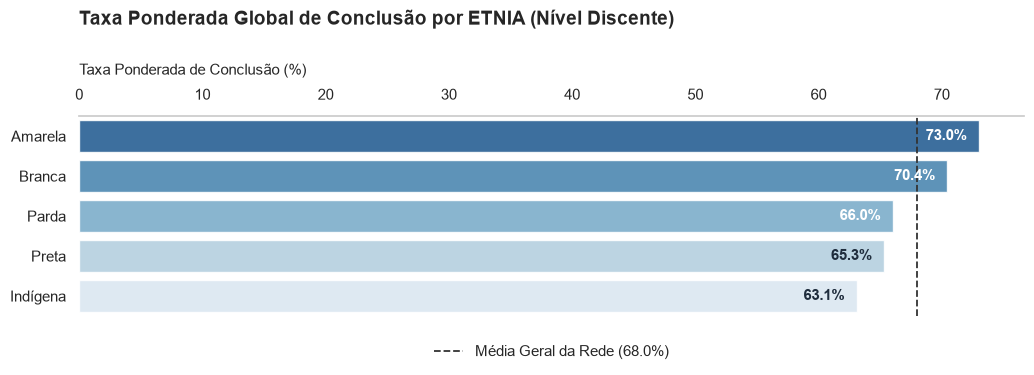


Etapa 04 - Verificação dos Pressupostos da ANOVA (Gauss-Markov)

p-valor Shapiro-Wilk (Normalidade): 3.3347e-09
p-valor Levene (Homocedasticidade): 2.7549e-01
Etapa 05 - Teste de Kruskal-Wallis (Não-Paramétrico) para ETNIA

Kruskal-Wallis: H = 9.5049 | p-valor = 4.9647e-02

Etapa 06 - Teste de Comparações Múltiplas (Mann-Whitney com Bonferroni) para ETNIA

Tabela 04. Estatística Descritiva Institucional para ETNIA (Nível Instituição)
------------------------------------------------------------------------------------------------
ETNIA       N_IFS  TAXA_MEDIA_IF  DESVIO_PADRAO  MEDIANA    MIN     MAX  TAXA_MEDIA_GERAL  GRUPO
------------------------------------------------------------------------------------------------
Amarela        38          56.55          17.45    51.31  35.18  105.29             73.02      a
Branca         38          52.67          13.79    49.50  28.26   81.95             70.45      a
Parda          38          50.20          14.03    46.03  31.20   87.84     

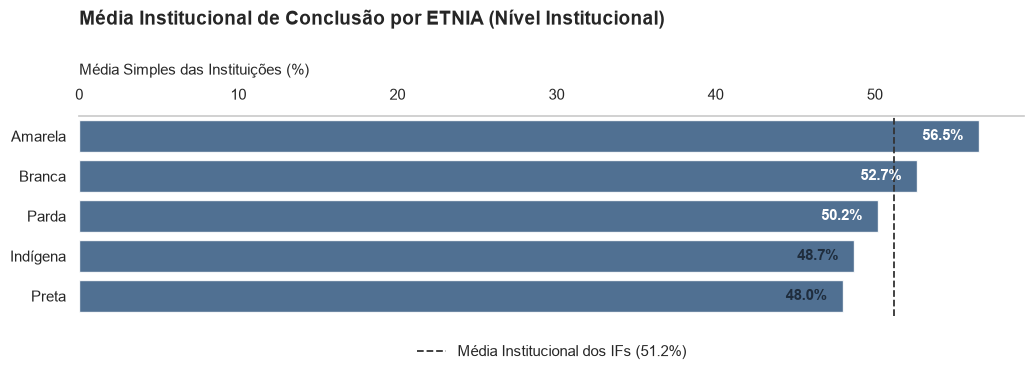


Etapa 08 - Gráfico de Boxplot com Strip Plot das Médias por IF para ETNIA



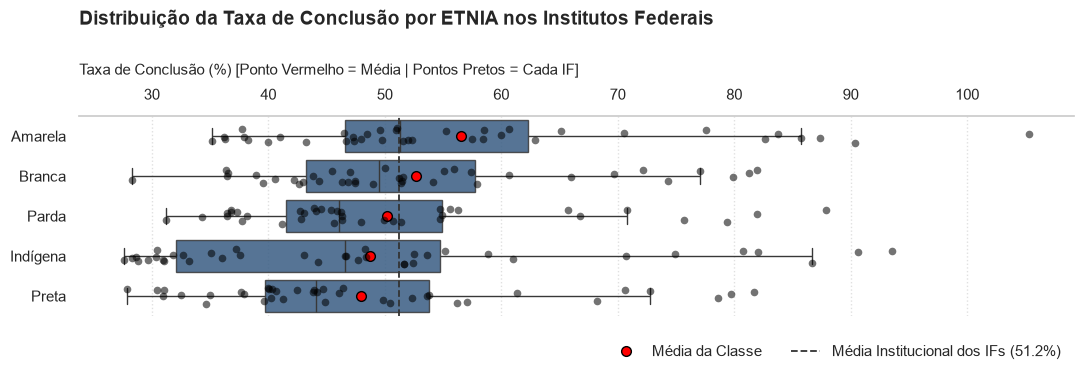

FAIXA_ETARIA

Etapa 01 - Análise Estatística Descritiva Inicial

Tabela 01. Análise Estatística Descritiva
---------------------------------------------------------------------------------------------
FAIXA_ETARIA    N_IFS  TAXA_MEDIA_IF  DESVIO_PADRAO  MEDIANA    MIN     MAX  TAXA_MEDIA_GERAL
---------------------------------------------------------------------------------------------
20 a 24            38          67.77          20.16    64.54  35.46  119.33             73.47
> 60               38          64.38          19.08    63.71  28.57  100.00             82.09
55 a 59            38          61.68          16.90    61.59  30.37   95.13             80.83
50 a 54            38          59.05          16.64    58.48  30.39   89.86             78.83
25 a 29            38          58.88          15.48    55.04  32.06   94.39             73.35
45 a 49            38          54.74          16.81    52.05  24.30   90.08             76.67
40 a 44            38          53.59          1

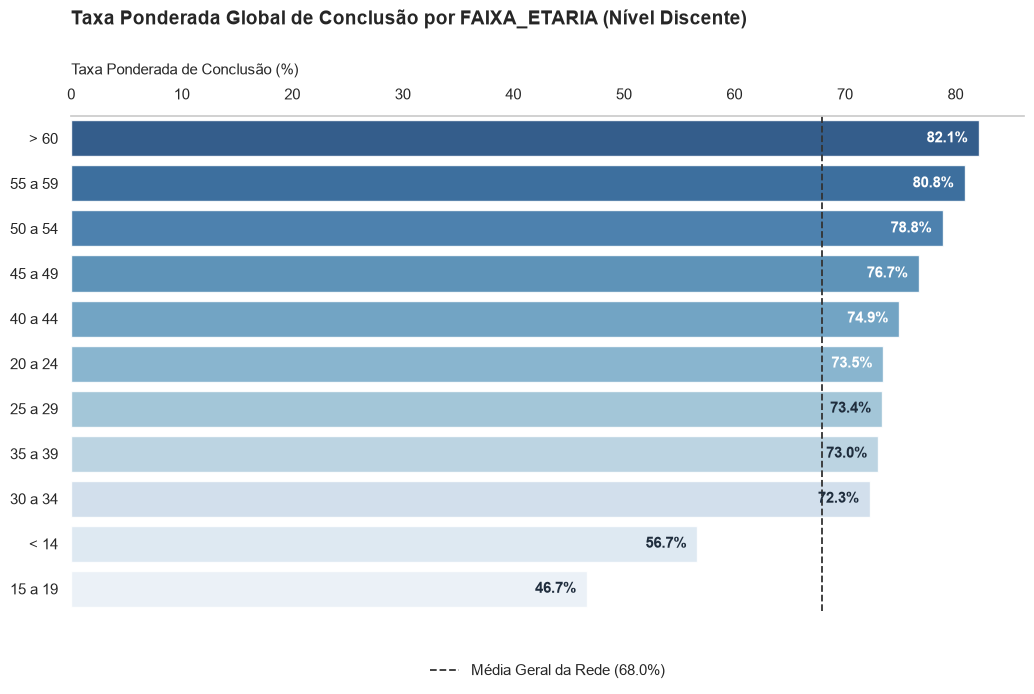


Etapa 04 - Verificação dos Pressupostos da ANOVA (Gauss-Markov)

p-valor Shapiro-Wilk (Normalidade): 3.8478e-07
p-valor Levene (Homocedasticidade): 1.8028e-03
Etapa 05 - Teste de Kruskal-Wallis (Não-Paramétrico) para FAIXA_ETARIA

Kruskal-Wallis: H = 80.4496 | p-valor = 4.0982e-13

Etapa 06 - Teste de Comparações Múltiplas (Mann-Whitney com Bonferroni) para FAIXA_ETARIA

Tabela 04. Estatística Descritiva Institucional para FAIXA_ETARIA (Nível Instituição)
----------------------------------------------------------------------------------------------------
FAIXA_ETARIA    N_IFS  TAXA_MEDIA_IF  DESVIO_PADRAO  MEDIANA    MIN     MAX  TAXA_MEDIA_GERAL  GRUPO
----------------------------------------------------------------------------------------------------
20 a 24            38          67.77          20.16    64.54  35.46  119.33             73.47      a
> 60               38          64.38          19.08    63.71  28.57  100.00             82.09     ab
55 a 59            38          61.

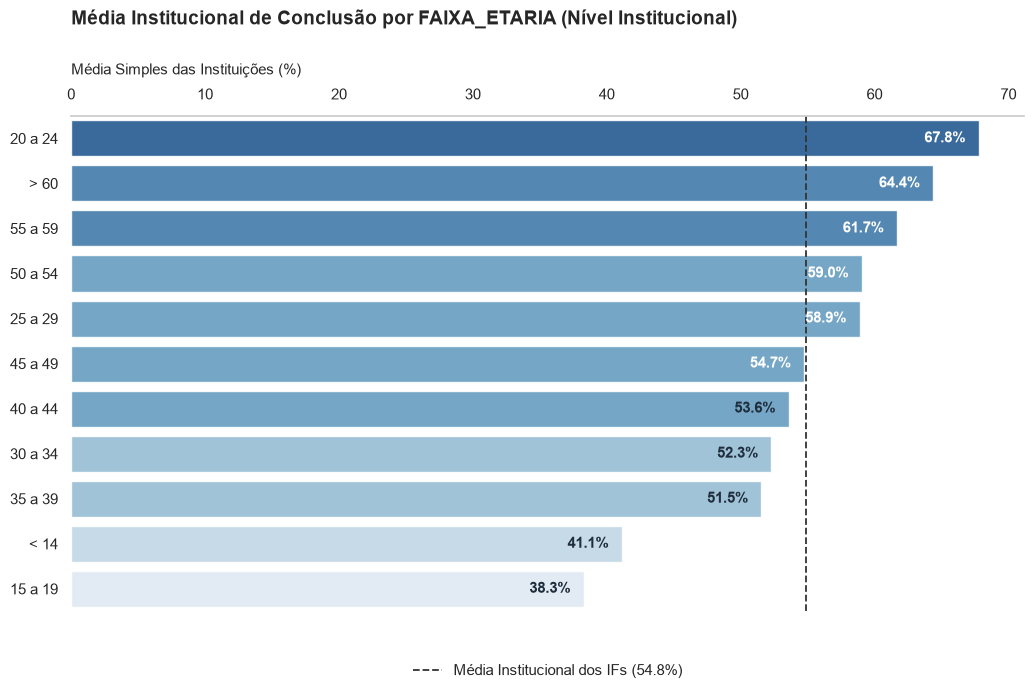


Etapa 08 - Gráfico de Boxplot com Strip Plot das Médias por IF para FAIXA_ETARIA



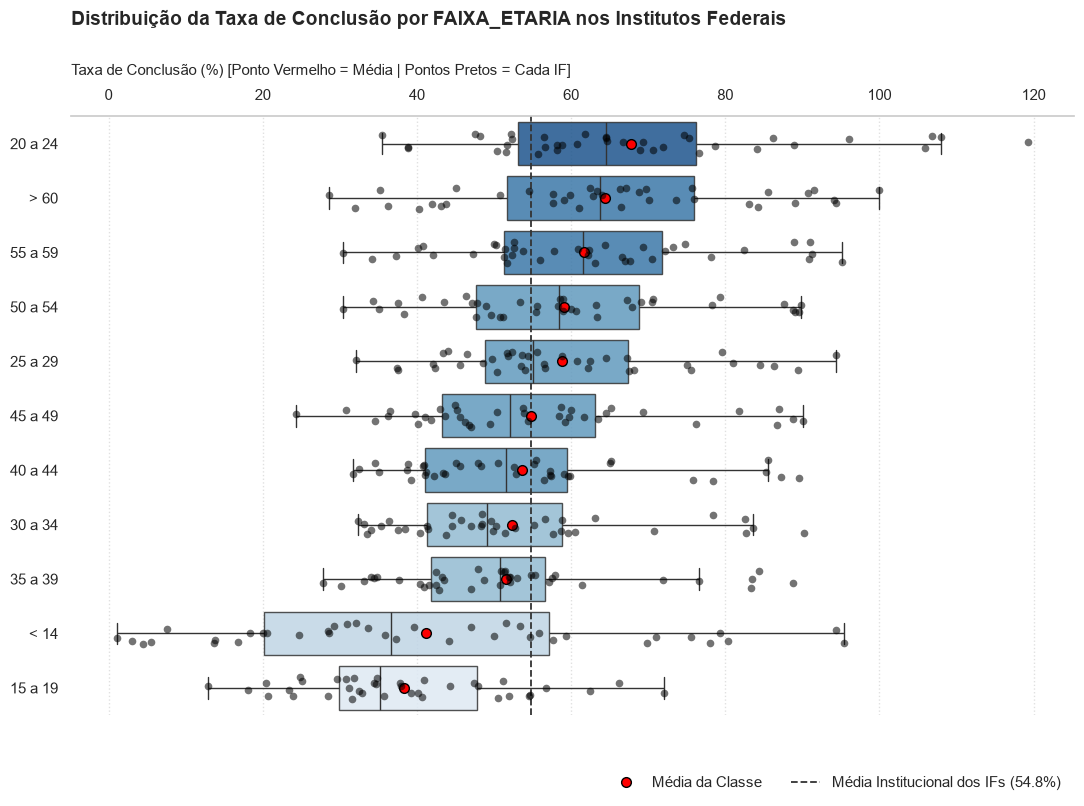

RENDA

Etapa 01 - Análise Estatística Descritiva Inicial

Tabela 01. Análise Estatística Descritiva
-------------------------------------------------------------------------------------------
RENDA          N_IFS  TAXA_MEDIA_IF  DESVIO_PADRAO  MEDIANA    MIN    MAX  TAXA_MEDIA_GERAL
-------------------------------------------------------------------------------------------
Alta              38          54.63          17.49    51.33  27.97  88.39             75.35
Média-Alta        38          52.94          15.64    49.22  26.95  88.47             74.93
Média             38          51.66          15.16    49.31  29.35  90.28             71.81
Baixa             38          51.56          13.68    47.75  33.54  81.16             66.56
Média-Baixa       38          49.82          15.27    46.91  28.13  87.93             69.71
Muito-Baixa       38          49.18          13.71    45.65  29.39  85.19             58.42
------------------------------------------------------------------------

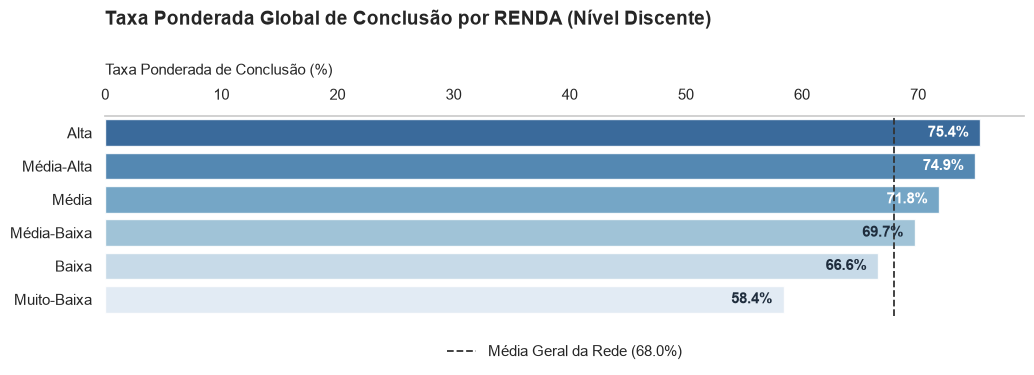


Etapa 04 - Verificação dos Pressupostos da ANOVA (Gauss-Markov)

p-valor Shapiro-Wilk (Normalidade): 3.4716e-08
p-valor Levene (Homocedasticidade): 6.2395e-01
Etapa 05 - Teste de Kruskal-Wallis (Não-Paramétrico) para RENDA

Kruskal-Wallis: H = 3.3903 | p-valor = 6.4005e-01

Não há diferença estatisticamente significante entre as medianas institucionais de RENDA (p >= 0.05).
SEXO

Etapa 01 - Análise Estatística Descritiva Inicial

Tabela 01. Análise Estatística Descritiva
-----------------------------------------------------------------------------------------
SEXO         N_IFS  TAXA_MEDIA_IF  DESVIO_PADRAO  MEDIANA    MIN    MAX  TAXA_MEDIA_GERAL
-----------------------------------------------------------------------------------------
Feminino        38          53.26          13.38    50.32  32.95  82.35             69.77
Masculino       38          48.60          13.78    43.92  28.05  82.30             65.47
-------------------------------------------------------------------------

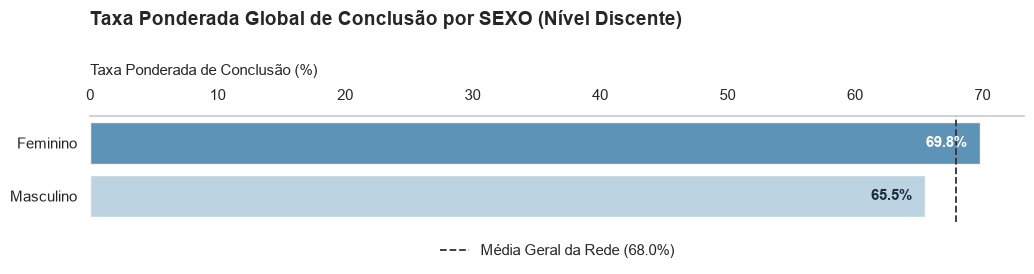


Etapa 04 - Verificação dos Pressupostos da ANOVA (Gauss-Markov)

p-valor Shapiro-Wilk (Normalidade): 1.1455e-05
p-valor Levene (Homocedasticidade): 9.5627e-01
Etapa 05 - Teste de Kruskal-Wallis (Não-Paramétrico) para SEXO

Kruskal-Wallis: H = 3.8961 | p-valor = 4.8398e-02



In [3]:
fatores = ['REGIAO', 'ETNIA', 'FAIXA_ETARIA', 'RENDA', 'SEXO']

for fator in fatores:

    # Cabeçalho
    print("=" * 100)
    print(f"{fator}")
    print("=" * 100)

    # -------------------------------------------------------------
    # BLOCO 1: NÍVEL DISCENTE (ESTUDANTES)
    # -------------------------------------------------------------
    print("\nEtapa 01 - Análise Estatística Descritiva Inicial\n")
    df_inst, tab_fator = prepara_dados_fator(df, fator)

    print("Tabela 01. Análise Estatística Descritiva")
    formata_tabela(tab_fator, fator)

    print("\nEtapa 02 - Teste Qui-Quadrado e V de Cramér (Nível Discente)")
    tab_chi, chi2, p_chi2, v_cramer, intensidade = executa_teste_quiquadrado(df, fator)

    print(f"Qui-Quadrado Global: χ² = {chi2:,.2f} | p-valor = {p_chi2:.4e}")
    print(f"Tamanho do Efeito Global (V de Cramér): V = {v_cramer:.4f} -> Associação {intensidade}")
    

    # Comparações Par a Par do Qui-Quadrado (se mais de 2 categorias e significante)
    if p_chi2 < 0.05 and df[fator].nunique() > 2:
        df_post_chi = executa_posthoc_quiquadrado(df, fator)
        
        if df_post_chi is not None:
            #print(f"Comparações Par a Par do Qui-Quadrado com V de Cramér ({fator}):")
            #formata_tabela(df_post_chi, 'Comparação')
            
            # Agrupamento Pós-hoc do Qui-Quadrado (Nível Discente)
            ordem_chi = tab_chi[fator].tolist()
            cld_chi, paleta_chi = gera_agrup_poshoc(
                fator=fator,
                df_posthoc=df_post_chi,
                p_global=p_chi2,
                ordem=ordem_chi,
                filtrar_residual=True  # Ou True, se quiser que pares residuais compartilhem letra!
            )

            tab_chi['GRUPO'] = tab_chi[fator].map(cld_chi)
            print(f"\nTabela 02. Análise de Contingência para {fator} (Nível Estudante)")
            formata_tabela(tab_chi, fator)
    

    print("\nEtapa 03 - Gráfico de Barras Horizontais das Médias Ponderadas (Nível Discente)\n")
    plota_barras_horizontais(df, tab_fator, fator, fator, stat='TAXA_MEDIA_GERAL')


    # -------------------------------------------------------------
    # BLOCO 2: NÍVEL INSTITUCIONAL (INSTITUTOS FEDERAIS)
    # -------------------------------------------------------------
    print("\nEtapa 04 - Verificação dos Pressupostos da ANOVA (Gauss-Markov)\n")
    p_shapiro, p_levene = verifica_pressupostos_anova(df_inst, fator)
    print(f"p-valor Shapiro-Wilk (Normalidade): {p_shapiro:.4e}")
    print(f"p-valor Levene (Homocedasticidade): {p_levene:.4e}")

    # Etapas 05 e 06: Teste Global + Pós-teste
    df_post = None
    if p_shapiro > 0.05 and p_levene > 0.05:
        print(f"\nEtapa 05 - ANOVA One-Way (Paramétrica) para {fator}\n")
        f_stat, p_global = executa_anova_oneway(df_inst, fator)
        print(f"ANOVA: F = {f_stat:.4f} | p-valor = {p_global:.4e}")
        
        if p_global < 0.05:
            print(f"\nEtapa 06 - Teste de Comparações Múltiplas (Tukey HSD) para {fator}")
            df_post = executa_tukey_hsd(df_inst, fator)
            # Agrupamento Pós-hoc Institucional: Letras CLD e Cores por patamar estatístico
            cld_map, paleta_cores = gera_agrup_poshoc(
                df_inst=df_inst,
                fator=fator,
                df_posthoc=df_post,
                p_global=p_global
            )
            # Tabela descritiva final com a coluna GRUPO (Compact Letter Display)
            print(f"\nTabela 04. Estatística Descritiva Institucional para {fator} (Nível Instituição)")
            tab_fator['GRUPO'] = tab_fator[fator].map(cld_map)
            formata_tabela(tab_fator, fator)
            # formata_tabela(df_post, 'Comparação')
            print(f"\nEtapa 07 - Gráfico de Barras Horizontais das Médias Institucionais para {fator}\n")
            plota_barras_horizontais(df, tab_fator, fator, fator, stat='TAXA_MEDIA_IF', df_inst=df_inst, paleta_cores=paleta_cores)

            print(f"\nEtapa 08 - Gráfico de Boxplot com Strip Plot das Médias por IF para {fator}\n")
            plota_boxplot_fator(df, df_inst, fator, fator, paleta_cores=paleta_cores)
        else:
            print(f"Não há diferença estatisticamente significante entre as médias institucionais de {fator} (p >= 0.05).")
    else:
        print(f"Etapa 05 - Teste de Kruskal-Wallis (Não-Paramétrico) para {fator}\n")
        h_stat, p_global = executa_kruskal_wallis(df_inst, fator)
        print(f"Kruskal-Wallis: H = {h_stat:.4f} | p-valor = {p_global:.4e}\n")

        if p_global < 0.05:
            if df_inst[fator].nunique() > 2:
                print(f"Etapa 06 - Teste de Comparações Múltiplas (Mann-Whitney com Bonferroni) para {fator}")
                df_post = executa_posthoc_mannwhitney(df_inst, fator)
                # Agrupamento Pós-hoc Institucional: Letras CLD e Cores por patamar estatístico
                cld_map, paleta_cores = gera_agrup_poshoc(
                    df_inst=df_inst,
                    fator=fator,
                    df_posthoc=df_post,
                    p_global=p_global
                )
                # Tabela descritiva final com a coluna GRUPO (Compact Letter Display)
                print(f"\nTabela 04. Estatística Descritiva Institucional para {fator} (Nível Instituição)")
                tab_fator['GRUPO'] = tab_fator[fator].map(cld_map)
                formata_tabela(tab_fator, fator)
                # formata_tabela(df_post, 'Comparação')
                print(f"\nEtapa 07 - Gráfico de Barras Horizontais das Médias Institucionais para {fator}\n")
                plota_barras_horizontais(df, tab_fator, fator, fator, stat='TAXA_MEDIA_IF', df_inst=df_inst, paleta_cores=paleta_cores)

                print(f"\nEtapa 08 - Gráfico de Boxplot com Strip Plot das Médias por IF para {fator}\n")
                plota_boxplot_fator(df, df_inst, fator, fator, paleta_cores=paleta_cores)
        else:
            print(f"Não há diferença estatisticamente significante entre as medianas institucionais de {fator} (p >= 0.05).")

